# Das Vektorraummodell als Grundlage automatisierter Verfahren im Information Retrieval und Text Mining

In [70]:
import datetime
# This cell has to be run to prepare the Jupyter notebook

# The %... is an Jupyter thing, and is not part of the Python language.
# In this case we're just telling the plotting library to draw things on
# the notebook, instead of on a separate window.
%matplotlib inline
# See all the "as ..." contructs? They're just aliasing the package names.
# That way we can call methods like plt.plot() instead of matplotlib.pyplot.plot().
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.width', 500)
pd.set_option('display.max_columns', 100)
pd.set_option('display.notebook_repr_html', True)

from time import time
from math import log
# import the k-means algorithm
from sklearn.cluster import KMeans

import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("poster")

## Agenda
* Abgrenzung zum Booleschen Retrievalmodell
* Nutzer-zentrierte Herleitung des Vektorraummodells
* Auswirkungen der natürlichen Sprache auf das Modell
* Vor- und Nachteile des Vektorraummodells
* Praktische Anwendungen im Text und Data Mining


## Boolesches Retrieval
* Relevanz wird anhand der Existenz des Anfrageterms im Dokument bestimmt 
  * Score = 1 für relevante Dokumente
  * Score = 0 für nichtrelevante Dokumente 
* Kein Ranking möglich, ein Dokument ist relevant oder nicht
* Extended Boolean Retrieval bringt Ranking
* Auch in relationalen Datenbanken verwendet, In Bibliotheken: OPAC

### Vorteile
* Simple Anfragen sind leicht zu verstehen

### Nachteile
* Schwierig, genaue Anfragen zu spezifizieren
* Logische Junktoren (UND, ODER) entsprechen nicht immer der natürlichen Sprache
* Ergebnismengen werden schnell zu klein oder zu groß, je nach Junktoren
* Ergebnis ist nur sortier- bzw. gruppierbar


## Nur ist der Nutzer immer so präzise?
### Nutzer sind sich im Unklaren...
* über den Informationsbedarf
* wie der Informationsbedarf formuliert werden kann
* was in der Kollektion enthalten ist
* was "gute" Ergebnisse sind, d.h.,
  * ob relevante Ergebnisse gefunden wurden
  * ob alle wichtigen Ergebnisse gefunden wurden 
* Dokumente, die einer Anfrage „ähnlich“ sind, sind wahrscheinlich relevant für diese Anfrage

[Kuhlthau 1991, Ingwersen 1996, Ellis/Haugan 1997, Reiterer et al. 2000] und viele mehr...


## Wie lässt sich Ähnlichkeit ausdrücken?
### Vom Dokument zum Vektor

* Dokumente und Anfrage repräsentiert durch t-dimensionale Vektoren 
* t ist Termanzahl des Indexvokabulars
* i-te Vektorkomponente ist Termgewicht $w_{dk}$ (reelle Zahl)
* Hohes Termgewicht ⇒ entsprechender Term repräsentiert Dokument/Anfrage gut

[Salton et al. 1975]

In [71]:
# create sample data
d = {'doc01': (1,2), 'doc02': (10,10),'doc03':(60,40),'doc04':(100,80),'doc05':(99,81),'doc06':(1,1),'doc07':(45,55),'doc08':(9,10),'doc09':(11,11),'doc10':(1,11)}
# create a data frame from our sample data
sampleDF=pd.DataFrame(data=d)
# transpose the data frame for later use
sampleDF=sampleDF.transpose()
sampleDF.columns = ['term 2 (z.B. Retrieval)', 'term 1 (z.B. Information)']
sampleDF.head(10)

,term 2 (z.B. Retrieval),term 1 (z.B. Information)
doc01,1,2
doc02,10,10
doc03,60,40
doc04,100,80
doc05,99,81
doc06,1,1
doc07,45,55
doc08,9,10
doc09,11,11
doc10,1,11


<Axes: xlabel='term 2 (z.B. Retrieval)', ylabel='term 1 (z.B. Information)'>

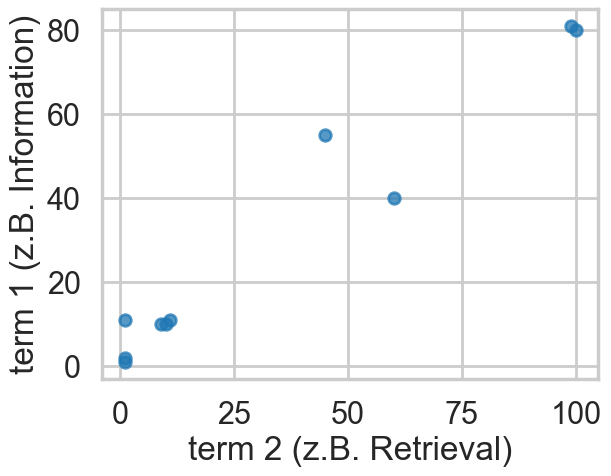

In [72]:
# plot the sample data

sampleDF.plot(x=0,y=1,kind='scatter',alpha=0.75,s=70) # we have to define explicitly which data is used for the x and y axes

### Clusterhypothese
“This hypothesis may be simply stated as follows: closely associated documents tend to be relevant to the same requests.”      		 	 	 		 	 	 								
[van Rijsbergen 1979, Ch. 3] 

#### Das Skalarprodukt als Ähnlichkeitsmaß

$$
similarity(V_Q,V_D)=<V_Q,V_D>=\sum_{k=1}^tw_{qk}w_{dk}=|V_Q||V_D|\cos(\alpha)
$$

### Vorkommenshäufigkeit des Terms im Dokument
* Vorkommenshäufigkeit $tf_{dk}$ des Terms im Dokument, desto besser beschreibt der Term das Dokument
* Achtung: absolute Vorkommenshäufigkeit bei langen Dokumenten tendenziell höher
* Konsequenz: lange Dokumente werden bei der Suche bevorzugt

In [73]:
vq=[0,1,1,0]
vd1=[50,5,0,0]
vd2=[0,2,2,0]
print("similarity between Vq and Vd1: %i"%np.inner(vq,vd1))# inner product is another name for the scalar/dot product
print("similarity between Vq and Vd2: %i"%np.inner(vq,vd2))

similarity between Vq and Vd1: 5
similarity between Vq and Vd2: 4


### Vorkommenshäufigkeit des Terms im Dokument

Unabhängigkeit von Dokumentlänge durch Normierung der Dokumentvektoren:

$$
w_{dk}=\frac{tf_{dk}}{\sqrt{\sum_{i=1}^t}tf_{di}^2}
$$

## Zipf's Law

Ordnet man Worte eines Textes nach ihrer Häufigkeit, so ist ihre Auftrittswahrscheinlichkeit p(n) umgekehrt proportional zu ihrer Position n innerhalb der Ordnung ⇒ Hyperbel
$$
p(n)\simeq \frac{1}{n}
$$

![title](../img/zipf.png)

### Zipf‘s Law als Motivation für Stoppworte
* Stoppworte: Worte, die aus dem Indexvokabular entfernt werden, weil sie...
  * häufig (oder zu selten) sind
  * "ohne Bedeutung" sind
* Wie wirken sich Stoppworte etc. auf Dokumentvektoren aus?
* Stoppwort-Eliminierung vermindert Möglichkeiten der Phrasensuche


In [74]:
# with stopword in first dimension
vq=[100,0,0,1,2]
b=[99,1,2,0,0]
c=[80,0,0,2,2]

print("Before stopword elimination")
print("\tsimilarity between Vq and b: %i"%np.inner(vq,b))
print("\tsimilarity between Vq and c: %i"%np.inner(vq,c))
# after stopword elimination
vq2=[0,0,1,2]
b2=[1,2,0,0]
c2=[0,0,2,2]

print("\nAfter stopword elimination")
print("\tsimilarity between Vq and b: %i"%np.inner(vq2,b2))
print("\tsimilarity between Vq and c: %i"%np.inner(vq2,c2))

Before stopword elimination
	similarity between Vq and b: 9900
	similarity between Vq and c: 8006

After stopword elimination
	similarity between Vq and b: 0
	similarity between Vq and c: 6


### Trennschärfe des Terms
* Wenn Term in weniger Dokumenten auftritt, ist er spezifischer
* Spezifischere Terme haben höhere Trennschärfe und sollten höher gewichtet werden
* Ansatz: Trennschärfe als Quotient: $N/n_i$

$$
w_{dk}=\frac{tf_{dk}\frac{N}{n_k}}{\sqrt{\sum_{i=1}^t}(tf_{di}\frac{N}{n_i})^2}
$$

* tf steht für term frequency
* idf steht für inverse document frequency
* tf∙idf-Formel ist heuristische Formel und in Varianten weit verbreitet
* wird auch in [Lucene](https://lucene.apache.org/core/4_0_0/core/org/apache/lucene/search/similarities/TFIDFSimilarity.html) und damit auch in [SOLR](http://lucene.apache.org/solr/) und [ElasticSearch](https://www.elastic.co/products/elasticsearch) genutzt


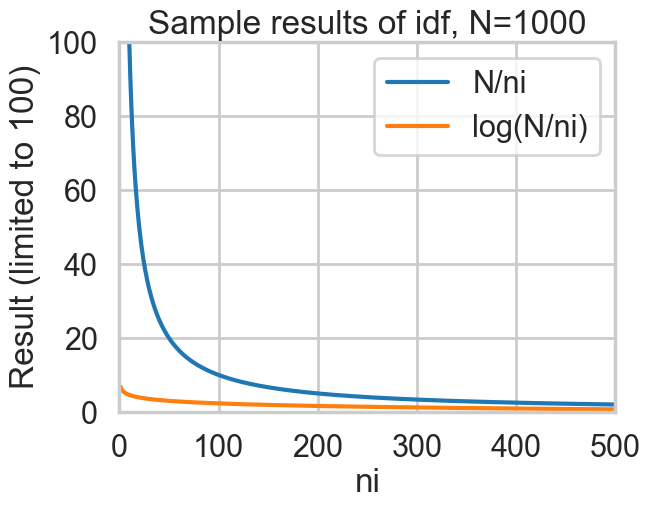

In [75]:
N=1000.0
ni=[]
quotient=[]
quotientLog=[]

for i in range(1,500):
    ni.append(i)

for i in ni:
    quotient.append(N/i)
    quotientLog.append(log(N/i))

plt.plot(ni,quotient,label="N/ni")
plt.plot(ni,quotientLog,label="log(N/ni)")
plt.axis([0, 500, 0, 100])
plt.ylabel('Result (limited to 100)')
plt.xlabel("ni")
plt.title("Sample results of idf, N=1000")
plt.legend()

## Bewertung des Vektorraummodells
### Nachteile:
* Geht von Unabhängigkeit der Terme aus
* Reihenfolge der Worte spielt keine Rolle (bag of words) 
* Keine theoretische Fundierung des Modells
* Anpassung an strukturierte Dokumente nur schwer möglich

### Vorteile
* Einfachheit
* Sehr gute empirische Retrieval-Qualität
* Effiziente Implementierung durch invertierte Listen
* Relevance Feedback verbessert Ergebnisqualität
* Direkt für Text Mining verwendbar
* Prinzipien auch auf multimediale Daten übertragbar


## Ausblick auf Anwendungen im Text Mining
### Clustering

In [76]:
# define the number of clusters to be found
true_k=3
# initialize the k-means algorithm
km = KMeans(n_clusters=true_k, init='k-means++', max_iter=100, n_init=1)
# apply the algorithm on the data
km.fit(sampleDF)
# add the detected clusters as a new column to the original data frame
sampleDF['cluster']=km.labels_
sampleDF=sampleDF.sort_values('cluster')
sampleDF.head(10)

,term 2 (z.B. Retrieval),term 1 (z.B. Information),cluster
doc04,100,80,0
doc05,99,81,0
doc01,1,2,1
doc02,10,10,1
doc06,1,1,1
doc08,9,10,1
doc09,11,11,1
doc10,1,11,1
doc03,60,40,2
doc07,45,55,2


In [77]:
clusterCenters=pd.DataFrame(data=km.cluster_centers_)
clusterCenters.head()

,0,1
0,99.5,80.5
1,5.5,7.5
2,52.5,47.5


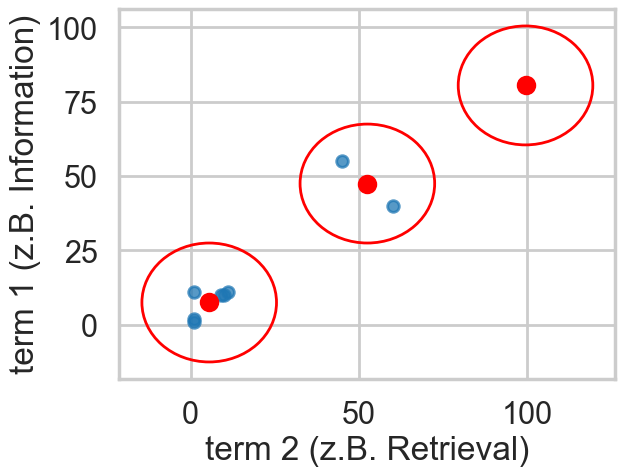

In [78]:
# plot the sample data and save the plot in the variable "ax"
ax=sampleDF.plot(x=0,y=1,kind='scatter',alpha=0.75,s=70)
# plot the centroids in red
plt.scatter(x=clusterCenters[0],y=clusterCenters[1],color='red')
# next, define the circles' centers surrounding the clusters for a better visualization result
cirlePos1=(clusterCenters[0][0],clusterCenters[1][0])
cirlePos2=(clusterCenters[0][1],clusterCenters[1][1])
cirlePos3=(clusterCenters[0][2],clusterCenters[1][2])
# create the unfilled circles with a radius of 20 (this value is arbitrary)
circ1=plt.Circle(cirlePos1,20,color='r',fill=False)
circ2=plt.Circle(cirlePos2,20,color='r',fill=False)
circ3=plt.Circle(cirlePos3,20,color='r',fill=False)
# add the circles to your plot
ax.add_patch(circ1)
ax.add_patch(circ2)
ax.add_patch(circ3)

## Weitere Beispiele

* [Beispiele für Maschinelles Lernen etc. mit diversen Beispielen; aufbereitet für MitarbeiterInnen der Stabi](https://github.com/elektrobohemian/dst4l-copenhagen)

## Weitere Werkzeuge

* [OpenRefine zur Datenbereinigung](http://openrefine.org/)
* [Gephi zur Visualisierung](https://gephi.org/)
* [Multimediales Retrieval](http://8bit-inferno.de/force/)

## Quellen

* [Kuhlthau 1991](https://www.google.de/url?sa=t&rct=j&q=&esrc=s&source=web&cd=1&cad=rja&uact=8&ved=0ahUKEwiUs9LoppHMAhUGthQKHTlRA3kQFggfMAA&url=https%3A%2F%2Fcomminfo.rutgers.edu%2F~kuhlthau%2Fdocs%2FInsidetheSearchProcess.pdf&usg=AFQjCNFa_wYoTfGIPSw8kqZP2QImVo9DLw&sig2=0uwO1GwwpwXM2WJWRF5frg&bvm=bv.119745492,d.bGg) Kuhlthau, C.C.: Inside the Search Process: Information Seeking from the User’s Perspective. Jrnl. o. t. American Soc. f. Information Science 42(5) (1991) 361–371 

* [Ingwersen 1996](http://www.emeraldinsight.com/doi/abs/10.1108/eb026960) Ingwersen, P.: Cognitive Perspectives of Information Retrieval Interaction: Elements of a Cognitive IR Theory. Journal of Documentation 52 (1996) 3–50 

* [Ellis/Haugan 1997](http://www.emeraldinsight.com/doi/abs/10.1108/EUM0000000007204) Ellis, D., Haugan, M.: Modelling the Information Seeking Patterns of Engineers and Research Scientists in an Industrial Environment. Journal of Documentation 
53(4) (1997) 384–403 

* [Reiterer et al. 2000](http://ftp.cse.buffalo.edu/users/azhang/disc/disc01/cd1/out/papers/sigir/p112-reiterer.pdf) Reiterer, H., Mußler, G., Mann, T., Handschuh, S.: INSYDER. In: Proc. of the 23rd SIGIR ’00, ACM (2000) 112–119 

* [Salton et al. 1975](http://dl.acm.org/citation.cfm?id=361220&CFID=104106607&CFTOKEN=66234087) Salton, G., Wong, A., Yang, C.S.: A vector space model for automatic indexing
October 1975 Communications of the ACM: Volume 18 Issue 11, Nov. 1975

* [van Rijsbergen 1979](http://www.dcs.gla.ac.uk/Keith/Preface.html) van Rijsbergen, Cornelis J.: Information Retrieval. 2. London : Butterworths, 1979 

* [Bates 1989](https://pages.gseis.ucla.edu/faculty/bates/berrypicking.html) Bates, M.: The Design of Browsing and Berrypicking Techniques for the Online Search Interface. Online Review 13(5) (1989) 407–424 


In [79]:
print(f"Done at {datetime.datetime.now()}")

Done at 2026-05-13 22:08:32.821965
